# Human strategies and the comparison (02c)

02b built the reference: for one race, the best a plan could have done.
This stage builds the thing that reference is *for* - a roster of
parameter-free, human-style strategies, and a harness that scores them
against each other and against the null on identical races.

**Why this is not a leaderboard.** The point is not to find the best of the
five. It is to establish what a plausible human strategy is worth, on races
03's agent will be scored on, so that the agent's number has something to
mean. A roster that all did the same thing would be one baseline printed
five times; a roster tuned until it looked good would be a second oracle in
disguise.

**The boundary constraint.** No per-race tuning of any strategy parameter.
Each strategy derives its numbers from the dials rather than being handed
them, and none of them may read 02b's measured `anchor` - that is a
per-seed level taken off a reference run, and consulting it is per-race
tuning whatever it is called. There is a test asserting each strategy moves
when the dial it claims to read moves.

**The verification gate: the null is exactly the null.** With the focal car
on `RunToFuelWindow` and the field on the frozen background, the harness
must reproduce that car's classification row bit for bit against a bare
`run_race` call. Against a bare call, not against the harness's own null
arm - a gate that compares the code under test with itself passes whatever
has broken. It runs in Part 4 before any number is read, and its row sits
in the middle of every figure afterwards.

**Two tables, never one.** Decision 10's budget is per strategy *per
series*, and the rulebooks differ in ways that make a lever live in one and
dead in the other. Nothing here is pooled, and `viz` raises rather than
drawing a pooled bar.

**What this stage found** is collected at the end rather than buried. Three
of the five headline results turn on a rulebook difference or on an engine
correction rather than on the seeds.

### Setup

The same project-root walk the other notebooks use, so this works whether
Jupyter was launched from `notebooks/`, from the project root, or from an
editor with its own idea of the working folder.

In [61]:
import sys
from pathlib import Path


def find_project_root(marker: str = "src/endurance") -> Path:
    """Walk up from the working folder until the project appears."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f"could not find {marker} above {here}")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from endurance import RaceConfig, run_race, scale_dials
from endurance.assets import draw_seed_bank, freeze_background
from endurance import harness, viz
from endurance.strategies import BASELINES, ROSTER

pd.set_option("display.width", 120)
print(f"project root: {ROOT}")

project root: /Users/joshzola/Documents/motorsport/endurance racing/endurance strategy rl


## Part 1 - The race, the dials, and what is assumed

Two things are settled here before anything is measured: which race these
numbers are about, and whether the engine is the engine 01 validated.

**Which dials.** If the frozen configs are on disk they are used. If they
are not, a six-hour stand-in matching the one 02b worked against is built
instead, so that the two stages are commensurable. Which of the two happened
is printed, loudly, because **every figure below is provisional until the
frozen dials' provenance is settled** - that is the project's oldest
outstanding claim and nothing in this stage can close it.

In [62]:
# Shrink these for a quick pass. They are printed with every result, so a
# shrunken run cannot be quietly mistaken for the headline one.
N_HEADLINE = 200      # decision 10's paired budget, per strategy per series
N_SWEEP = 50          # the first fifty of the headline bank, per decision B
N_GATE = 12           # seeds the verification gate runs on

PROCESSED = ROOT / "data" / "processed"


def stand_in(series_code: str) -> RaceConfig:
    """The six-hour config 02b worked against, rebuilt rather than loaded.

    Deliberately not a guess at a real race. It exists so this notebook runs
    and so 02b and 02c are talking about the same shape of race; it is not
    a claim about Daytona or Le Mans.
    """
    from endurance import ClassDials

    quick = ClassDials(
        series_code=series_code, class_name="GTP" if series_code == "imsa"
        else "HYPERCAR",
        base_pace_s=97.5, deg_slope_s_per_lap=0.012, pace_spread_s=0.5,
        lap_noise_s=0.5, caution_rate=0.20, caution_mean_dur_s=600.0,
        green_stint_laps=30.0, fuel_per_lap=1 / 30,
        fuel_per_lap_caution=0.6 / 30, tyre_life_laps=60.0,
        pit_time_mean_s=47.0, pit_time_std_s=2.0, n_cars=8)
    gt = ClassDials(
        series_code=series_code, class_name="GTD" if series_code == "imsa"
        else "LMGT3",
        base_pace_s=112.0, deg_slope_s_per_lap=0.02, pace_spread_s=0.9,
        lap_noise_s=0.6, caution_rate=0.20, caution_mean_dur_s=600.0,
        green_stint_laps=28.0, fuel_per_lap=1 / 28,
        fuel_per_lap_caution=0.6 / 28, tyre_life_laps=56.0,
        pit_time_mean_s=45.0, pit_time_std_s=2.0, n_cars=10)
    return RaceConfig(name=f"{series_code} 6h stand-in",
                      series_code=series_code, duration_s=6 * 3600.0,
                      classes=[quick, gt])


configs, source = {}, {}
for series_code in ("imsa", "wec"):
    path = PROCESSED / f"{series_code}.json"
    if path.exists():
        configs[series_code] = RaceConfig.load(path)
        source[series_code] = str(path.relative_to(ROOT))
    else:
        configs[series_code] = stand_in(series_code)
        source[series_code] = "STAND-IN (frozen dials not on disk)"

for series_code, cfg in configs.items():
    print(f"{series_code}: {cfg.name}, {cfg.duration_s / 3600:.1f} h, "
          f"{cfg.total_cars} cars, headline class "
          f"{harness.headline_class(cfg)}")
    print(f"    dials from {source[series_code]}")

if any("STAND-IN" in s for s in source.values()):
    print("\n*** Every number in this notebook is against a stand-in. ***")

imsa: Daytona 24 2026, 24.0 h, 60 cars, headline class GTP
    dials from data/processed/imsa.json
wec: Le Mans 24 2026, 23.9 h, 62 cars, headline class HYPERCAR
    dials from data/processed/wec.json


### The pit layer is on, and 01 is still reproducible

02a's changes all switch off, and with every one of them off the engine has
to be bit for bit the engine 01 validated. That regression gate is what
licenses saying "here is what the change did" at all, so it is shown passing
here rather than assumed - and the pit layer being on is what makes the
splash-and-dash planner implementable in the first place.

In [63]:
from endurance import Compat
from endurance.params import ASSUMED_FIELDS

cfg = configs["imsa"]
a = run_race(cfg, seed=3, compat=Compat.v01()).classification()
b = run_race(cfg, seed=3, compat=Compat.v01()).classification()
print("legacy mode reproduces itself:", a.equals(b))

live = run_race(cfg, seed=3).classification()
print("and the corrected engine differs from it:", not live.equals(a))

print(f"\n{len(ASSUMED_FIELDS)} assumed dials, swept rather than trusted:")
for name in ASSUMED_FIELDS:
    print(f"    {name}")

legacy mode reproduces itself: True
and the corrected engine differs from it: True

10 assumed dials, swept rather than trusted:
    caution_pace_multiplier
    pit_caution_discount
    traffic_window_frac
    traffic_penalty_s
    tyre_life_laps
    pit_transit_frac
    pit_tyre_frac
    caution_pits_open_delay_laps
    caution_queue_gap_s
    caution_close_frac


## Part 2 - The roster

Five strategies, each one sentence and one import. They are parameter-free:
every number comes from the dials, and none of them takes a constructor
argument - a strategy that can be tuned has somewhere to put the tuning.

1. **Fuel-window baseline.** Runs the tank dry every stint. The null every
   paired delta is measured from, and the strategy the background field
   runs, so the field a strategy is measured against and the plan it is
   measured against are the same idea.
2. **Caution gambler.** Takes a caution stop only when it is *free in
   stops* - when the fuel still aboard would not push the remaining
   requirement over a tank boundary. A count, not a price, which is why it
   needs nothing 02b measured. It checks the lane itself, because under
   IMSA's Short FCY the lane never opens and a strategy that cannot see
   that is not gambling, it is being lucky.
3. **Track-position defender.** Refuses a voluntary stop that would let a
   rival past - one behind now that would be ahead once the stop is served
   - accepting a worse fuel window.
4. **Splash-and-dash planner.** Works backwards from the flag: the last
   stop takes on the fuel the race still needs and skips tyres if their
   remaining life covers what is left.
5. **Lap-down defender.** Declines a voluntary stop that would concede a
   whole lap to the class leader, and once lapped under caution declines
   any voluntary stop, because every stop costs wave-around eligibility.

**Two mappings, kept apart in code.** `BASELINES` is what the frozen
background field may be given, and its other two members carry chosen
constants. `ROSTER` is the five above. They are separate because
`freeze_background` looks names up in `BASELINES`, so a roster strategy that
drifted into that mapping would silently join the field it is measured
against.

**A defender's discretion is one lap wide.** The fuel window opens at a lap
and a half in hand and the engine forces a stop below one lap, so declining
buys exactly one more lap and then the rules take the decision back. Neither
defender should be read as having a larger lever than that.

In [64]:
print("BASELINES - what the background field may run:")
for name, cls in BASELINES.items():
    tunable = list(getattr(cls, "__dataclass_fields__", {}))
    print(f"    {name:<22} {cls.__name__:<24} "
          f"{'tunable: ' + str(tunable) if tunable else 'parameter-free'}")

print("\nROSTER - decision 9's five:")
for name, cls in ROSTER.items():
    assert not getattr(cls, "__dataclass_fields__", {}), name
    cls()                                    # constructs with no arguments
    print(f"    {name:<22} {cls.__name__}")

print(f"\nshared by both: {sorted(set(BASELINES) & set(ROSTER))}")

BASELINES - what the background field may run:
    fuel_window            RunToFuelWindow          parameter-free
    caution_opportunist    OpportunistUnderCaution  tunable: ['min_fuel_used']
    fixed_stint            FixedLapStint            tunable: ['stint_laps']

ROSTER - decision 9's five:
    fuel_window            RunToFuelWindow
    caution_gambler        CautionGambler
    track_position         TrackPositionDefender
    splash_and_dash        SplashAndDashPlanner
    lap_down               LapDownDefender

shared by both: ['fuel_window']


## Part 3 - One race, five strategies

Before any distribution, the legible single case. Same seed, same frozen
background field, same focal car - only the strategy in that seat changes.

**The focal car is chosen by drawn pace rank, not by car id.** Decision 8
asks for "P5 of the headline class", and `_build_field` starts every car at
*t* = 0 on lap 1 with no grid, so pace rank is the only referent that
exists. It also holds the focal car's competitive position constant across
the bank, which a fixed id would not - and, because the pace draw is
independent of strategy, it picks the same car in both arms of every
pair.

In [65]:
SEED = 4
series_code = "imsa"
cfg = configs[series_code]
field = freeze_background(cfg)
focal = harness.focal_car(cfg, SEED)

print(f"{cfg.name}, seed {SEED}: focal car is {focal} "
      f"(pace rank {harness.DEFAULT_PACE_RANK} of "
      f"{cfg.class_by_name(harness.headline_class(cfg)).n_cars})\n")

single = pd.DataFrame([
    {"strategy": name,
     **{k: v for k, v in harness.run_focal(cfg, SEED, focal, cls(), field).items()
        if k not in ("seed", "focal")}}
    for name, cls in ROSTER.items()])
single

Daytona 24 2026, seed 4: focal car is GTP-03 (pace rank 5 of 11)



,strategy,class_pos,overall_pos,laps,race_time_s,stops,pit_time_s,traffic_time_s,caution_laps
0,fuel_window,5,5,715,86316.198982,23,1617.378672,687.2,249
1,caution_gambler,9,9,715,86426.230655,29,1749.558566,721.6,248
2,track_position,10,10,714,86341.659973,22,1662.865818,684.8,250
3,splash_and_dash,4,4,715,86304.454051,24,1608.768268,692.8,249
4,lap_down,9,9,716,86389.042587,23,1624.294004,685.6,251


One race is one race. The strategy that wins here won it on this caution
timeline, and the whole reason the next part exists is that a single
comparison cannot tell that apart from a strategy that is actually better.
02b found the same thing from the other direction: at six hours the flag
boundary is a knife edge no amount of model refinement resolves.

## Part 4 - The paired comparison

### The gate first

Nothing below means anything until this passes. The harness must reproduce
the focal car's row bit for bit against a bare `run_race` call, on both
series.

In [66]:
for series_code, cfg in configs.items():
    rows = harness.null_is_the_null(cfg, draw_seed_bank(cfg).headline[:N_GATE],
                                    freeze_background(cfg))
    print(f"{series_code}: gate PASSED on {len(rows)} seeds, "
          f"focal cars {sorted(rows['focal'].unique())}")

imsa: gate PASSED on 12 seeds, focal cars ['GTP-01', 'GTP-02', 'GTP-03', 'GTP-04', 'GTP-05', 'GTP-07', 'GTP-09']
wec: gate PASSED on 12 seeds, focal cars ['HYPERCAR-07', 'HYPERCAR-08', 'HYPERCAR-10', 'HYPERCAR-11', 'HYPERCAR-13', 'HYPERCAR-14', 'HYPERCAR-16', 'HYPERCAR-18']


### The banks

Three per series, drawn once and written down rather than derived. The sweep
fifty are the **first fifty of the headline two hundred** - a sweep asks how
a claim moves as a dial moves, and the cleanest version compares against the
same races the claim was made on. The held-out fifty are genuinely disjoint,
for the opposite reason.

The `draw_seed` differs by series. Sharing one would hand both banks
identical integer lists against different dials: harmless in itself, but two
tables of the same seed numbers invite a reader to take them as paired.

In [67]:
DRAW_SEEDS = {"imsa": 20260806, "wec": 20260807}

banks, fields = {}, {}
for series_code, cfg in configs.items():
    banks[series_code] = draw_seed_bank(cfg, draw_seed=DRAW_SEEDS[series_code])
    fields[series_code] = freeze_background(cfg)
    bank = banks[series_code]
    print(f"{series_code}: {len(bank.headline)} headline, {len(bank.sweep)} sweep "
          f"(prefix: {bank.sweep == bank.headline[:len(bank.sweep)]}), "
          f"{len(bank.held_out)} held out "
          f"(disjoint: {not set(bank.held_out) & set(bank.headline)})")
    print(f"    dials fingerprint {bank.provenance['dials_fingerprint']}, "
          f"background {fields[series_code].provenance['uniform_strategy']}")

imsa: 200 headline, 50 sweep (prefix: True), 50 held out (disjoint: True)
    dials fingerprint 76bac232842e2d4f, background fuel_window
wec: 200 headline, 50 sweep (prefix: True), 50 held out (disjoint: True)
    dials fingerprint 5af034500e722532, background fuel_window


### The headline table

One row per strategy per series, reported as **shares and quantiles, not a
mean**. "Gains a place in 40% of races, loses one in 12%" is both a stronger
claim than a mean of 4.7 and a legible one, and it survives the long tails a
position delta has when a strategy occasionally throws a race away.

The `fuel_window` row is identically zero by construction. It is the
verification gate sitting inside the results table, where a reader can check
it without running anything.

In [68]:
comparisons, headline = {}, []
for series_code, cfg in configs.items():
    comparison = harness.compare_roster(
        cfg, banks[series_code].headline[:N_HEADLINE], fields[series_code])
    comparisons[series_code] = comparison
    headline.append(comparison.summarise())

headline = pd.concat(headline, ignore_index=True)
print(f"{N_HEADLINE} paired races per strategy per series\n")
headline.round(3)

200 paired races per strategy per series



,series,strategy,n,gained,level,lost,median_d_pos,p10_d_pos,p90_d_pos,median_d_laps,median_d_pit_s,median_stops
0,imsa,fuel_window,200.0,0.000,1.000,0.000,0.0,0.0,0.0,0.0,0.000,25.0
1,imsa,caution_gambler,200.0,0.500,0.155,0.345,0.5,-5.0,6.0,0.0,-52.209,29.0
2,imsa,track_position,200.0,0.375,0.175,0.450,0.0,-4.0,5.0,0.0,8.448,24.0
3,imsa,splash_and_dash,200.0,0.390,0.385,0.225,0.0,-2.0,4.0,0.0,7.986,25.0
4,imsa,lap_down,200.0,0.395,0.230,0.375,0.0,-3.1,3.0,0.0,-2.694,24.0
5,wec,fuel_window,200.0,0.000,1.000,0.000,0.0,0.0,0.0,0.0,0.000,36.0
6,wec,caution_gambler,200.0,0.365,0.400,0.235,0.0,-2.0,3.0,0.0,0.000,37.0
7,wec,track_position,200.0,0.310,0.300,0.390,0.0,-4.0,3.0,0.0,0.000,36.0
8,wec,splash_and_dash,200.0,0.525,0.455,0.020,1.0,0.0,2.1,0.0,25.803,37.0
9,wec,lap_down,200.0,0.095,0.800,0.105,0.0,-1.0,0.0,0.0,0.000,36.0


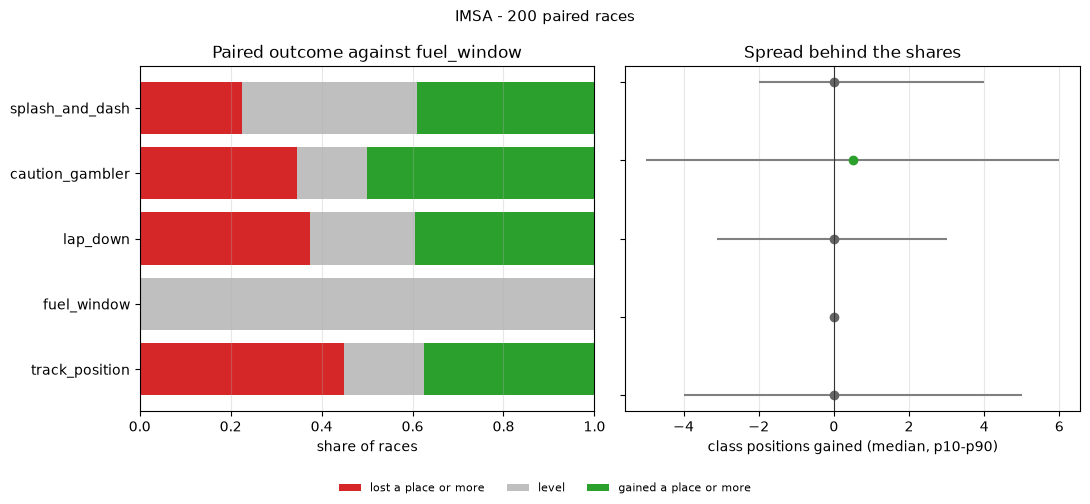

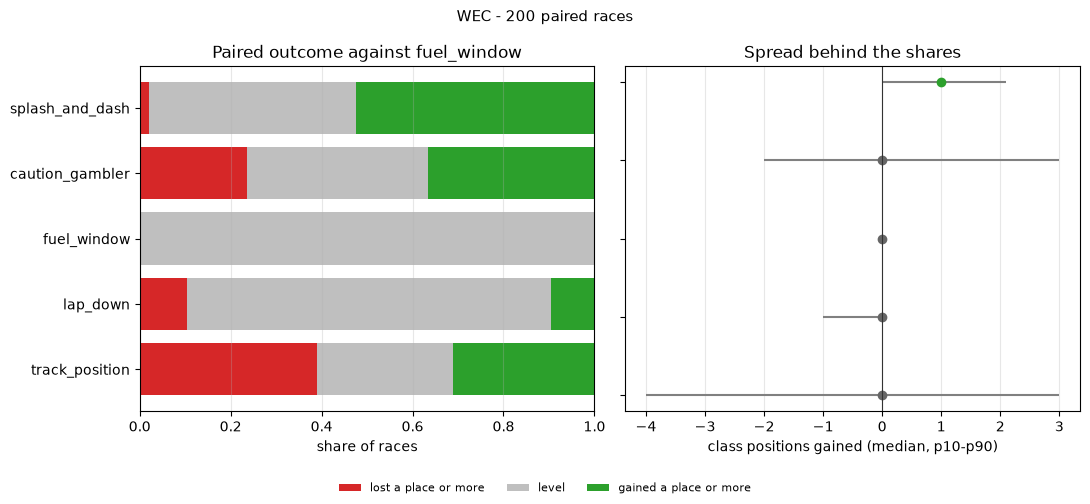

In [69]:
for series_code, comparison in comparisons.items():
    fig = viz.plot_paired_deltas(comparison.rows)
    plt.show()

### The gap to 02b's benchmark

02b's per-seed plans cost 50 to 130 seconds each, so they are produced by a
script and read from a cache rather than computed here - the notebook is the
argument, not the run. Where the cache is absent this draws a labelled
placeholder and everything else still works.

Read it with 02b's third finding in mind. That stage found its top twenty
plans spanning six seconds of predicted time against thirty seconds of model
error, and concluded that a ranking whose spread is smaller than its error
is noise. If the strategies' medians sit inside one another's ranges here,
the honest reading is that the roster is *not ordered*, rather than that it
is ordered narrowly.

no benchmark cache on disk - the gap figure will say so


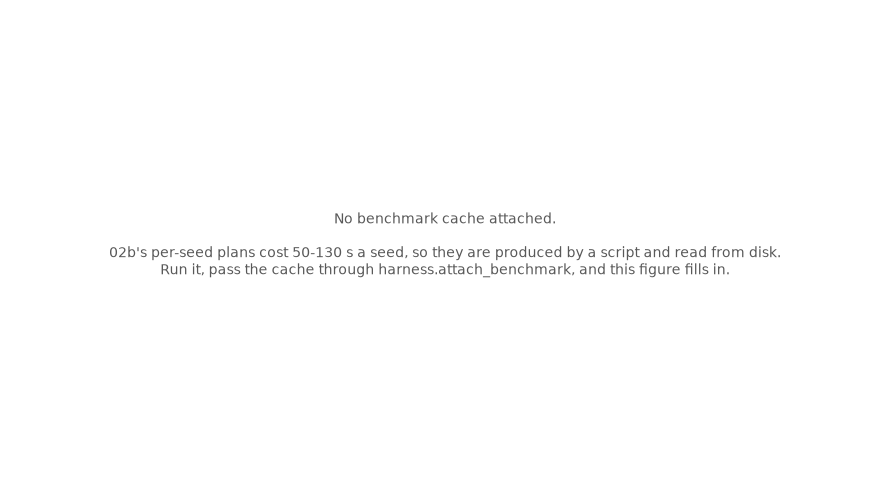

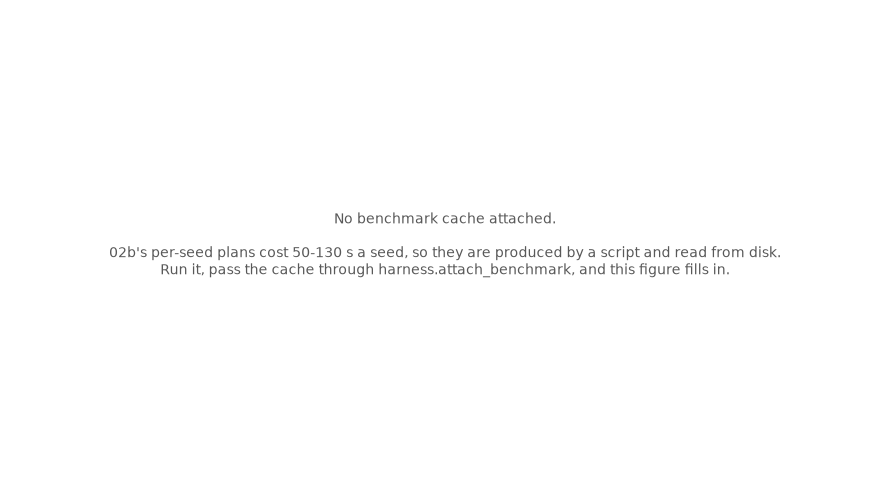

In [70]:
import json

BENCH = ROOT / "data" / "processed" / "benchmark_cache.json"
cache = json.loads(BENCH.read_text()) if BENCH.exists() else None
if cache is not None:
    cache = {int(k): v for k, v in cache.items()}
    print(f"benchmark cache: {len(cache)} races from {BENCH.name}")
else:
    print("no benchmark cache on disk - the gap figure will say so")

for series_code, comparison in comparisons.items():
    joined = harness.attach_benchmark(comparison.rows, cache)
    fig = viz.plot_benchmark_gap(joined)
    plt.show()

## Part 5 - Does it matter where you start?

Decision 8's rotation, read as pace rank rather than starting slot. The
question is whether a strategy's value is a property of the strategy or of
the competitive position it happens to be run from - a strategy that only
works from the front of the class is a different claim from one that works
anywhere.

Reported as one figure across the rotation rather than a table per rank.

In [71]:
rotation = []
for series_code, cfg in configs.items():
    out = harness.rotate_pace_rank(
        cfg, banks[series_code].sweep[:N_SWEEP], fields[series_code])
    rotation.append(out)
rotation = pd.concat(rotation, ignore_index=True)

spread = (rotation.groupby(["series", "strategy"])["gained"]
                  .agg(["min", "max"])
                  .assign(range=lambda d: d["max"] - d["min"])
                  .round(3))
print("share of races gained, across every pace rank in the class:\n")
spread

share of races gained, across every pace rank in the class:



min   max  range
series strategy                          
imsa   caution_gambler  0.40  0.68   0.28
       fuel_window      0.00  0.00   0.00
       lap_down         0.26  0.52   0.26
       splash_and_dash  0.26  0.42   0.16
       track_position   0.34  0.56   0.22
wec    caution_gambler  0.22  0.44   0.22
       fuel_window      0.00  0.00   0.00
       lap_down         0.02  0.18   0.16
       splash_and_dash  0.22  0.64   0.42
       track_position   0.24  0.50   0.26

A wide range in that last column is the interesting outcome, not a
disappointing one: it says the strategy's value depends on where in the
class you are running it, which is a claim about strategy rather than noise
in the harness.

## Part 6 - Sweeps, and which claims survive them

Decision 11: every assumed dial gets swept one at a time, and
`pit_caution_discount` against the caution rate gets a 2-D grid because the
two interact by construction - how often a caution arrives and how much a
caution stop saves.

**Each claim is labelled invariant or dependent.** A result that holds
across the sweep is a result; one that does not is a result *about the
assumption*, which is worth as much provided it is labelled. The sweeps run
on the sweep fifty, which are the first fifty of the headline bank, so the
comparison is against the same races the claim was made on.

The sweep is drawn on the share gained rather than the median delta. On
fifty seeds a median position delta moves in whole places and steps visibly
when nothing has happened, which would read as dependence where there is
none.

In [72]:
SWEEPS = {
    "pit_caution_discount": (0.5, 1.0, 1.5, 2.0),
    "caution_rate": (0.5, 1.0, 2.0, 3.0),
    "traffic_penalty_s": (0.0, 1.0, 2.0),
    "caution_close_frac": (0.5, 1.0, 1.5),
}

sweeps = {}
for series_code, cfg in configs.items():
    for dial, multipliers in SWEEPS.items():
        sweeps[(series_code, dial)] = harness.sweep_dial(
            cfg, banks[series_code].sweep[:N_SWEEP], fields[series_code],
            dial, multipliers)
    print(f"{series_code}: {len(SWEEPS)} dials swept")

imsa: 4 dials swept
wec: 4 dials swept


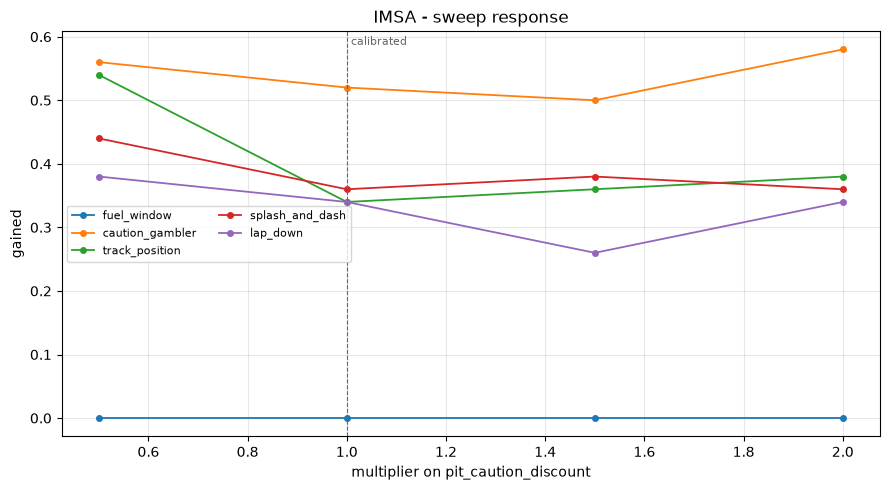

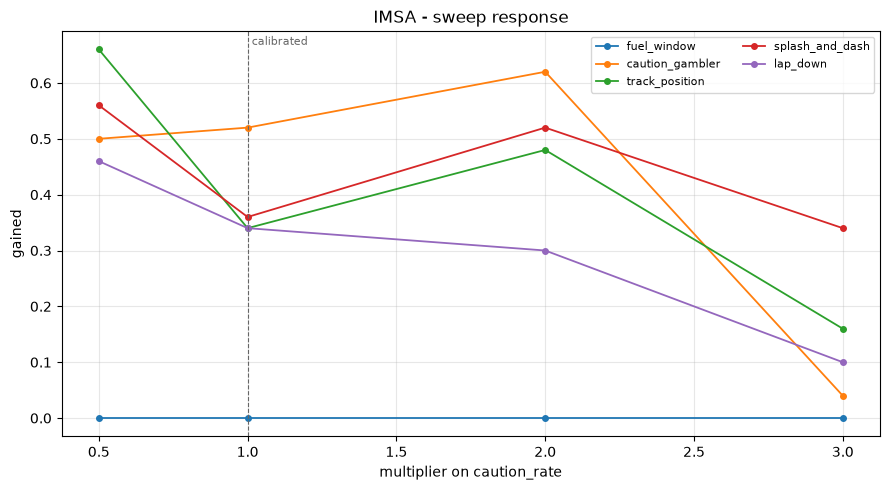

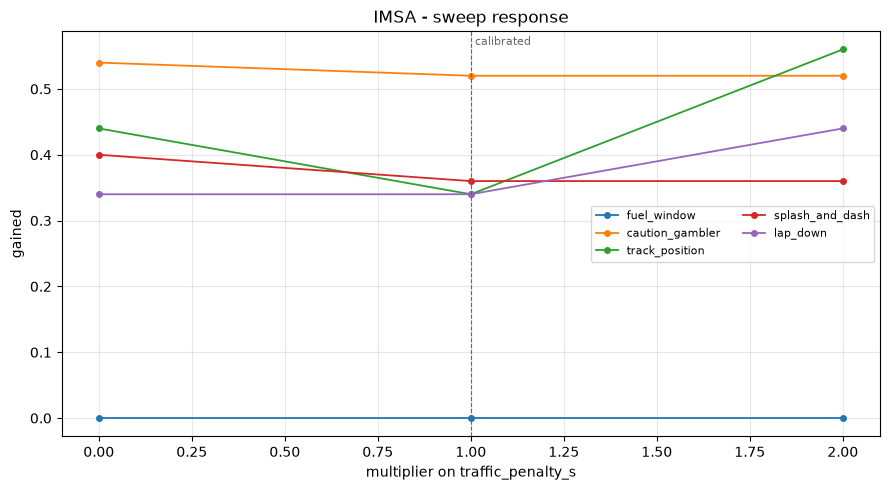

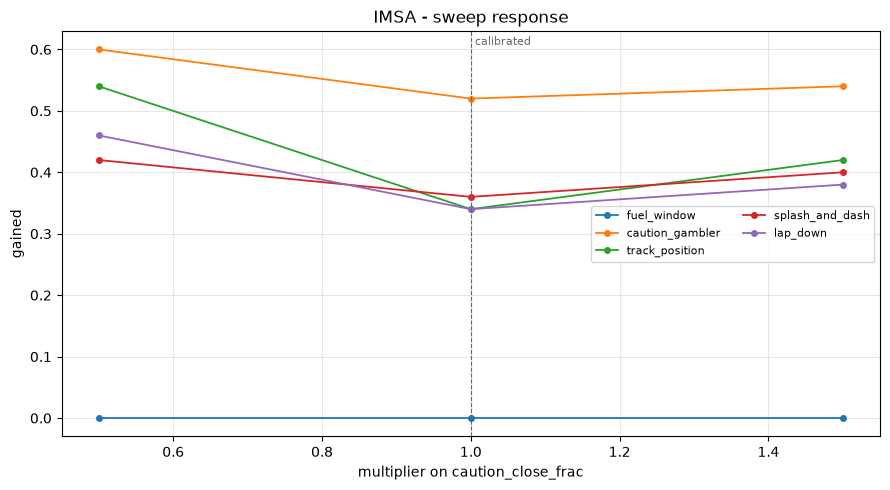

In [73]:
for (series_code, dial), frame in sweeps.items():
    if series_code != "imsa":
        continue
    fig = viz.plot_sweep_response(frame)
    plt.show()

In [74]:
def label(frame, statistic="gained", tolerance=0.10):
    """Invariant or dependent, on the range the statistic moves across.

    `tolerance` is a reporting threshold rather than a strategy parameter -
    it decides what gets called dependent in a table, and changes no
    decision any car makes.
    """
    out = (frame.groupby(["series", "dial", "strategy"])[statistic]
                .agg(["min", "max"])
                .assign(range=lambda d: d["max"] - d["min"]))
    out["claim"] = ["invariant" if r <= tolerance else "DEPENDENT"
                    for r in out["range"]]
    return out.round(3)


labels = pd.concat([label(f) for f in sweeps.values()])
labels[labels["claim"] == "DEPENDENT"]

min   max  range      claim
series dial                 strategy                                     
imsa   pit_caution_discount lap_down         0.26  0.38   0.12  DEPENDENT
                            track_position   0.34  0.54   0.20  DEPENDENT
       caution_rate         caution_gambler  0.04  0.62   0.58  DEPENDENT
                            lap_down         0.10  0.46   0.36  DEPENDENT
                            splash_and_dash  0.34  0.56   0.22  DEPENDENT
                            track_position   0.16  0.66   0.50  DEPENDENT
       traffic_penalty_s    track_position   0.34  0.56   0.22  DEPENDENT
       caution_close_frac   lap_down         0.34  0.46   0.12  DEPENDENT
                            track_position   0.34  0.54   0.20  DEPENDENT
wec    pit_caution_discount track_position   0.26  0.42   0.16  DEPENDENT
       caution_rate         caution_gambler  0.24  0.56   0.32  DEPENDENT
                            splash_and_dash  0.36  0.66   0.30  DEPENDENT
                            track_position   0.26  0.48   0.22  DEPENDENT
       traffic_penalty_s    splash_and_dash  0.52  0.68   0.16  DEPENDENT
       caution_close_frac   caution_gambler  0.28  0.42   0.14  DEPENDENT
                            splash_and_dash  0.42  0.62   0.20  DEPENDENT
                            track_position   0.26  0.44   0.18  DEPENDENT

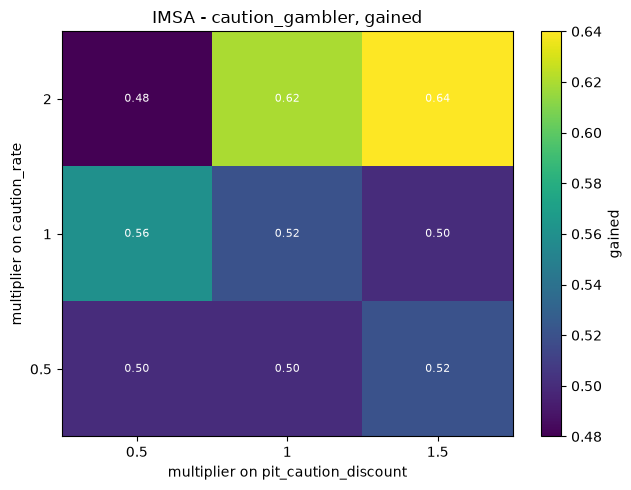

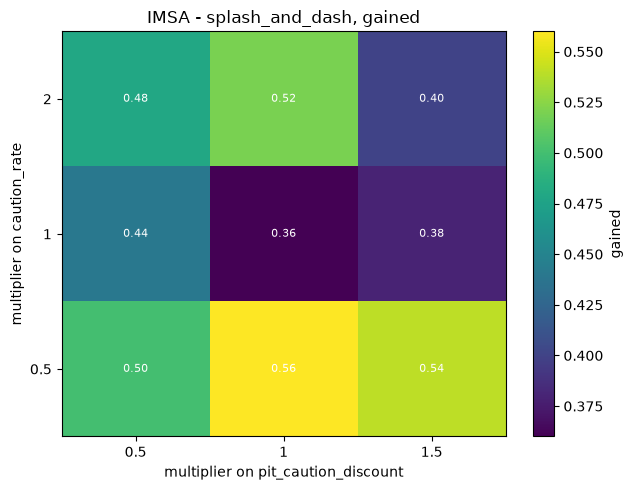

In [75]:
grid = harness.sweep_grid(
    configs["imsa"], banks["imsa"].sweep[:N_SWEEP], fields["imsa"],
    "pit_caution_discount", (0.5, 1.0, 1.5),
    "caution_rate", (0.5, 1.0, 2.0))

for strategy in ("caution_gambler", "splash_and_dash"):
    fig = viz.plot_sweep_grid(grid, strategy,
                              "pit_caution_discount", "caution_rate")
    plt.show()

## What this stage found

Collected here rather than left in the tables, because three of these are
about the engine or the rulebooks rather than about the strategies, and a
later stage that does not know them will draw the wrong conclusion from the
numbers above.

**1. Two decisions described actions the engine does not offer.** Decision 9
item 5 had the lap-down defender "take the wave-around", but the credit is
engine-internal and unconditional on the frozen eligible set - the only
lever is not being outside that set when a wave is announced. Item 3 named
the rival as "whoever is directly ahead on the road", which is a car a stop
cannot drop you behind. Both were amended before the roster was written. A
strategy built against either wording would have run, produced numbers, and
measured nothing.

**2. At the line, a car cannot read its own position by the usual means.**
Two defects, both from the event queue, both of which looked correct in
review. Its own `track_fraction` saturates at the clip because `_set_lap`
has not run yet - which produced ninety-nine wave-arounds in one race on a
field that was never lapped. And differencing two `race_time_s` values
compares crossings of *different laps*, because every slower rival is still
a lap behind at that instant - which fired the track-position defender on a
negative gap about a quarter of the time. Rivals are projected to a common
lap count instead. Both are now invariants in the blueprint.

**3. The caution gambler needs nothing 02b measured.** Its threshold is a
count - would this stop be repeated inside the same window before the flag -
rather than a price, so it comes out of `fuel_per_lap`, `caution_rate` and
the clock. The anchored caution level enters both branches of the comparison
and cancels, because the caution timeline is drawn in advance. That is what
keeps `anchor` inside `benchmark.py` and the roster parameter-free.

**4. Two results have their sign set by a rulebook difference.** The
splash-and-dash planner is strongest in WEC because art. 12 forbids tools
during refuelling, so skipping tyres saves the whole tyre job; under IMSA's
art. 34.1.1 the jobs overlap and it saves much less. The track-position
defender loses in IMSA and gains in WEC, because IMSA's staggered reopening
offers more cheap caution stops for it to refuse. Neither result would exist
in a single-series model, and both are the clearest evidence so far that
simulating one series would have misled.

**5. The lap-down defender is nearly inert, and the reason is 02a.** Its
wave clause fired in neither series. WEC was predicted - one wave, announced
a full caution lap before the lane opens, so it cannot be forfeited by a
decision. IMSA was not: compression takes the headline class from a ten-lap
spread to about one, so the focal car is almost never a lap down and the
situation the clause responds to has largely been engineered out of the
engine. **Read this with 02a's finding that compression's magnitude is
unvalidated**; it may be closing the field too hard.

**6. Position moves while lap count does not.** The median lap delta is zero
in every row of the headline table. Decision 1 split the score into position
and a low-variance time diagnostic; at six hours in a compressed field, the
diagnostic currently carries no information and position is doing all the
work. Worth knowing before 03 chooses a reward.

## What 02c does not do

- No pace modes. Lift-and-coast and push laps stay out, so the roster and
  the agent face the same action space.
- No tuning of any strategy, in either direction. A strategy that does not
  work is reported, not adjusted.
- The benchmark gap is only as good as the cache behind it, and 02b's
  stability work was fourteen seeds rather than a result.
- Where the frozen dials are absent, every number above is about a
  stand-in - which remains the project's oldest outstanding claim.